Latihan Mandiri

1. Klasifikasi Flynn

Operasi arr + arr pada NumPy array
Kategori : SIMD
Alasan   : Operasi tersebut melakukan penjumlahan terhadap banyak elemen array dengan satu jenis operasi yang sama, sehingga akan menghasilkan penjumlahan setiap elemen yang bersesuaian.

Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris
Kategori : SISD
Alasan   : Karena program menjalankan satu aliran instruksi secara berurutan dan memproses data satu per satu. Misalnya, ketika program membaca sebuah file, program mengambil satu baris, melakukan pemrosesan, kemudian berpindah ke baris berikutnya.

Cluster komputer yang setiap node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen
Kategori : MIMD
Alasan   : Setiap node dapat menjalankan instruksi dan mengolah data yang berbeda sesuai dengan wilayah yang disimulasikan.

2. Analisis Amdahl (memiliki proporsi paralel P = 0.85

In [2]:
import pandas as pd
def amdahl_speedup(P, N):
    """Menghitung speedup teoritis berdasarkan Hukum Amdahl"""
    return 1 / ((1 - P) + (P / N))

P = 0.85
N_values = [2, 4, 8, 16, 32, 64]

speedups = [amdahl_speedup(P, N) for N in N_values]

hasil_amdahl = pd.DataFrame({
    'Jumlah Prosesor (N)': N_values,
    'Speedup Teoritis': speedups
})

hasil_amdahl

,Jumlah Prosesor (N),Speedup Teoritis
0,2,1.739130
1,4,2.758621
2,8,3.902439
3,16,4.923077
4,32,5.663717
5,64,6.124402


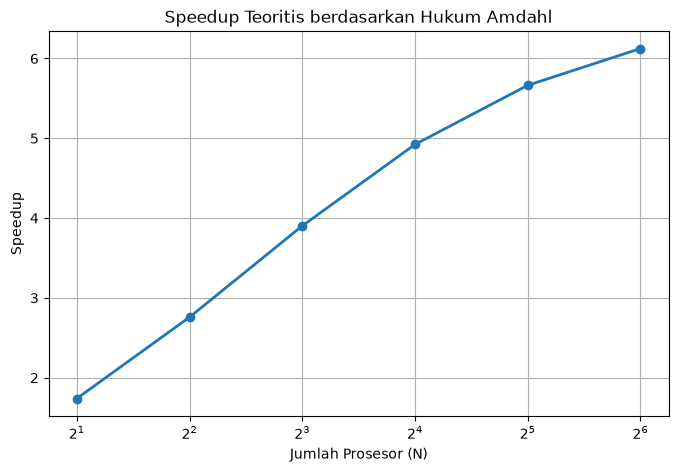

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(N_values, speedups, marker='o', linewidth=2)
plt.title('Speedup Teoritis berdasarkan Hukum Amdahl')
plt.xlabel('Jumlah Prosesor (N)')
plt.ylabel('Speedup')
plt.xticks(N_values)
plt.xscale('log', base=2)
plt.grid(True)
plt.show()

Penambahan prosesor mulai memberikan manfaat yang semakin kecil setelah sekitar `N = 16` hingga `N = 32`. Penyebabnya adalah bagian serial sebesar 15% tidak dapat diparalelkan. Ketika jumlah prosesor bertambah, waktu bagian paralel semakin kecil, tetapi waktu bagian serial tetap ada. Akibatnya, speedup mendekati batas maksimum : 

S maksimum = 1/1-P 
           = 1/0.15
           = 6.67

Artinya, walaupun jumlah prosesor terus ditambah, speedup teoritis tidak dapat melebihi sekitar 6,67 kali selama proporsi serial program tetap sebesar 15%. Grafik speedup terhadap jumlah prosesor akan menunjukkan kurva yang meningkat kemudian semakin mendatar mendekati batas maksimum tersebut.

3. Benchmark Mandiri

Fungsi berikut menghitung jumlah bilangan prima sampai batas tertentu. Fungsi ini sengaja dibuat CPU-bound dengan pemeriksaan pembagi secara berulang.

In [16]:
import math

def hitung_prima(n):
    """Menghitung banyaknya bilangan prima dari 2 sampai n."""
    jumlah_prima = 0

    for angka in range(2, n + 1):
        prima = True

        for pembagi in range(2, int(math.sqrt(angka)) + 1):
            if angka % pembagi == 0:
                prima = False
                break

        if prima:
            jumlah_prima += 1

    return jumlah_prima

In [17]:
import math
import time
import pandas as pd

ukuran_input = [5000, 10000, 15000, 20000]
hasil_benchmark = []

for n in ukuran_input:
    mulai = time.perf_counter()
    hasil = hitung_prima(n)
    selesai = time.perf_counter()

    waktu = selesai - mulai
    hasil_benchmark.append({
        'Input n': n,
        'Jumlah Prima': hasil,
        'Waktu Eksekusi (detik)': waktu
    })

tabel_benchmark = pd.DataFrame(hasil_benchmark)
tabel_benchmark

,Input n,Jumlah Prima,Waktu Eksekusi (detik)
0,5000,669,0.006004
1,10000,1229,0.014066
2,15000,1754,0.020229
3,20000,2262,0.028821


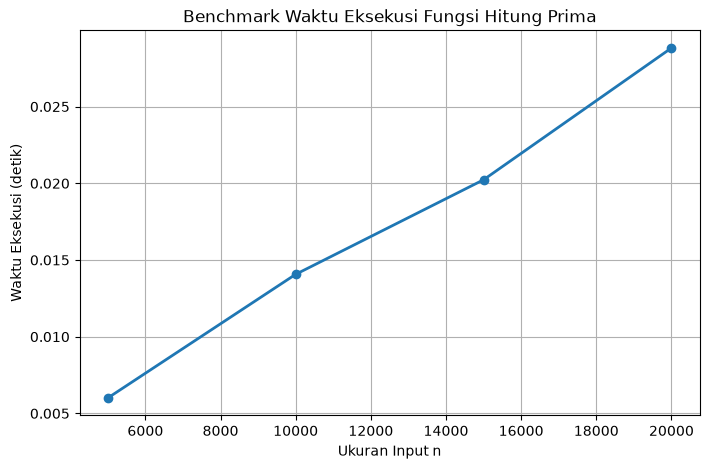

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(
    tabel_benchmark['Input n'],
    tabel_benchmark['Waktu Eksekusi (detik)'],
    marker='o',
    linewidth=2
)
plt.title('Benchmark Waktu Eksekusi Fungsi Hitung Prima')
plt.xlabel('Ukuran Input n')
plt.ylabel('Waktu Eksekusi (detik)')
plt.grid(True)
plt.show()

4. Refleksi Singkat

Hukum Amdahl lebih relevan ketika ukuran masalah relatif tetap dan kita ingin mengetahui seberapa besar percepatan yang dapat diperoleh dengan menambah prosesor. Hukum ini memperlihatkan bahwa bagian serial program akan menjadi batas speedup, sehingga cocok digunakan untuk menganalisis aplikasi yang memiliki proporsi pekerjaan serial yang cukup besar. Contoh nyatanya adalah aplikasi pengolahan citra dengan ukuran gambar tetap. Walaupun jumlah core ditambah, bagian pembacaan file dan penyimpanan hasil tetap membutuhkan waktu.

Sebaliknya, Hukum Gustafson lebih relevan ketika jumlah prosesor bertambah dan ukuran masalah juga dapat diperbesar. Hukum ini digunakan untuk melihat bagaimana sistem paralel mampu menyelesaikan masalah yang lebih besar dalam waktu yang relatif sama. Contoh nyatanya adalah simulasi cuaca atau simulasi ilmiah pada superkomputer. Ketika jumlah node bertambah, wilayah, resolusi, atau jumlah langkah simulasi dapat diperbesar sehingga pekerjaan yang diselesaikan juga meningkat. Dengan demikian, Amdahl menekankan batas speedup pada ukuran masalah tetap, sedangkan Gustafson menekankan peningkatan ukuran masalah yang dapat diselesaikan.